# 解說
這一篇承襲20260225Feb_code資料夾裡的 "OU_NoTrain-2D Spiral_betaSigmaConst" 這一篇。  
1. 先試試看 Training的時候仍然是用$L_{DSM}$，但可以算算看$I_{DSM}(\theta)$ (output仍然是$\theta$)
2. **驗證指標:** 如果算出來的值接近**0**, 就代表效果好。

# Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sample_p0_mix(n_points=2500):
    theta = np.sqrt(np.random.rand(n_points)) * 6 * np.pi # 角度
    r = 1 * theta 
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    data = np.stack([x, y], axis=1) + np.random.randn(n_points, 2) * 0.1
    return data

In [2]:
beta = 1.0   #<<<<<<<<<<<<<<<<<<<
sigma = 5.0
t = 10
x0 = sample_p0_mix(n_points=2500)

mu_t = np.exp(-beta * t) * x0
var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
std_t = np.sqrt(var_t)
xt = mu_t + std_t * np.random.randn(*x0.shape)


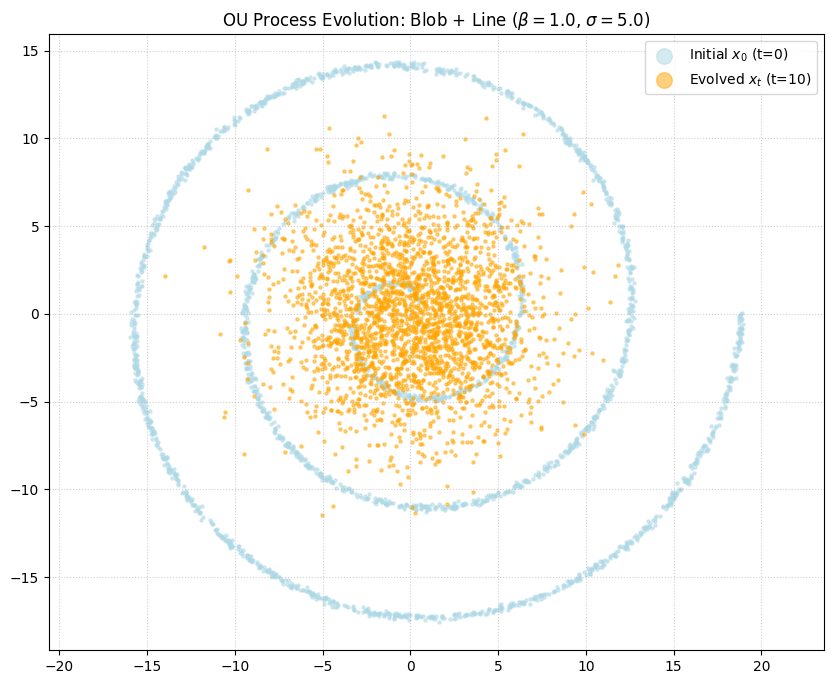

In [3]:
plt.figure(figsize=(10, 8))
plt.scatter(x0[:, 0], x0[:, 1], color='lightblue', s=5, alpha=0.5, label='Initial $x_0$ (t=0)')
plt.scatter(xt[:, 0], xt[:, 1], color='orange', s=5, alpha=0.5, label=f'Evolved $x_t$ (t={t})')

plt.title(fr'OU Process Evolution: Blob + Line ($\beta={beta}$, $\sigma={sigma}$)')
plt.legend(markerscale=5)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), 
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [ ]:
def train(model, beta, sigma, T, steps):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for i in range(steps):
        x0_np = sample_p0_mix(n_points=2500)
        x0 = torch.tensor(x0_np, dtype=torch.float32)
        t = torch.rand(x0.shape[0]) * T
        mu_t = torch.exp(-beta * t).view(-1, 1) * x0
        std_t = torch.sqrt((sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t))).view(-1, 1)
        eps = torch.randn_like(x0)
        xt = mu_t + std_t * eps
        
        optimizer.zero_grad()
        eps_pred = model(xt, t)
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        if i % 500 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}")
    